In [21]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset
from collections import deque
import torch.optim as optim
from typing import Optional
import re
import logging

In [ ]:
# 設定 logging 等級為 INFO，可根據需要調整為 DEBUG 以顯示更多細節
logging.basicConfig(level=logging.INFO)

# 定義時間嵌入的維度，後續模型中會用到此參數
TIME_EMB_DIM = 128

######################################
# 1. 資料前處理與數據集定義 (PeopleFlowDatasetCondition)
######################################
def parse_lat_lon(column_name):
            """
            解析欄位名稱中的經緯度。
    
            Args:
                column_name (str): 欄位名稱，格式如 "(lon,lat)"。
    
            Returns:
                tuple: (經度, 緯度)，分別為浮點數。
    
            Raises:
                ValueError: 若欄位名稱格式無效。
            """
            match = re.search(r'\(([\d.-]+),\s*([\d.-]+)\)', column_name)
            if match:
                lon = float(match.group(1))  # 提取經度
                lat = float(match.group(2))  # 提取緯度
                return lon, lat
            else:
                raise ValueError(f"欄位名稱格式無效：{column_name}")

class PeopleFlowDatasetCondition(Dataset):
    """
    此類別負責從 CSV 檔案中讀取人流數據
    並根據指定網格大小 (H x W)、歷史序列長度 (condition_length) 與預測序列長度 (prediction_length)
    進行數據切割與預處理。
    """
    def __init__(self, csv_path: str, H: int, W: int, condition_length: int, prediction_length: int,
                 transform: Optional[callable] = None, normalize: bool = True, debug: bool = False):
        # 檢查 CSV 檔案是否存在，若不存在則拋出錯誤
        if not os.path.exists(csv_path):
            raise FileNotFoundError(f"CSV 檔案未找到，路徑為 {csv_path}")
        # 讀取 CSV 檔案
        self.df = pd.read_csv(csv_path)
        self.transform = transform
        # 歷史與預測序列長度設定
        self.condition_length = condition_length
        self.prediction_length = prediction_length
        # 總序列長度 = 歷史長度 + 預測長度
        self.total_length = condition_length + prediction_length
        # 是否標準化數據
        self.normalize = normalize
        
        flow_columns = [c for c in self.df.columns if '(' in c and ')' in c]

        # 將每個欄位名稱解析為 (名稱, 經度, 緯度) 的元組列表
        column_info = [(col, *parse_lat_lon(col)) for col in flow_columns]

        # 將所有座標轉為 NumPy 陣列，方便計算，形狀為 (509, 2)
        coords = np.array([(lon, lat) for _, lon, lat in column_info])

        # 計算所有座標的平均經緯度，作為中心點的參考
        mean_lon = np.mean(coords[:, 0])  # 平均經度
        mean_lat = np.mean(coords[:, 1])  # 平均緯度

        # 計算每個座標到平均經緯度的歐氏距離，找到最接近的中心點
        distances_to_center = np.sqrt((coords[:, 0] - mean_lon)**2 + (coords[:, 1] - mean_lat)**2)
        central_idx = np.argmin(distances_to_center)  # 中心點的索引
        central_coord = coords[central_idx]  # 中心點的經緯度

        # 定義網格大小為 21x21，共 441 個位置
        grid_size = 21
        # 初始化網格，所有位置設為 -1，表示未分配
        grid = np.full((grid_size, grid_size), -1, dtype=int)
        # 設定中心點位置為 (10, 10)，並分配中心座標的索引
        central_row, central_col = 10, 10
        grid[central_row, central_col] = central_idx

        # 估計網格的經緯度間距（步長），基於座標差異的中位數
        lon_diffs = np.diff(np.sort(coords[:, 0]))  # 經度差異
        lat_diffs = np.diff(np.sort(coords[:, 1]))  # 緯度差異
        # 若差異存在，取中位數；否則使用預設值 0.005
        lon_step = np.median(lon_diffs[lon_diffs > 0]) if len(lon_diffs) > 0 else 0.005
        lat_step = np.median(lat_diffs[lat_diffs > 0]) if len(lat_diffs) > 0 else 0.005

        # 初始化可用座標索引列表，排除中心點
        available_indices = list(range(len(coords)))
        available_indices.remove(central_idx)

        # 生成按環層排序的網格位置列表，使用 Chebyshev 距離
        grid_positions = []
        for k in range(11):  # k 從 0 到 10，表示從中心到最外層
            for r in range(max(0, 10 - k), min(21, 10 + k + 1)):  # 行範圍
                for c in range(max(0, 10 - k), min(21, 10 + k + 1)):  # 列範圍
                    # 檢查是否屬於當前環層 k
                    if max(abs(r - 10), abs(c - 10)) == k:
                        grid_positions.append((r, c))

        # 按環層分配座標到網格
        for r, c in grid_positions:
            if grid[r, c] != -1:  # 若該位置已分配，跳過
                continue
    
            # 計算目標經緯度，基於中心點和網格間距
            target_lon = central_coord[0] + (c - central_col) * lon_step
            target_lat = central_coord[1] - (r - central_row) * lat_step
    
            # 設定方向約束，根據位置相對中心的關係
            lon_constraint = None
            if c < central_col:  # 左側，要求經度小於中心
                lon_constraint = lambda x: x < central_coord[0]
            elif c > central_col:  # 右側，要求經度大於中心
                lon_constraint = lambda x: x > central_coord[0]
    
            lat_constraint = None
            if r < central_row:  # 上方，要求緯度大於中心
                lat_constraint = lambda x: x > central_coord[1]
            elif r > central_row:  # 下方，要求緯度小於中心
                lat_constraint = lambda x: x < central_coord[1]
    
            # 篩選符合方向約束的座標索引
            filtered_indices = [idx for idx in available_indices if
                                (lon_constraint is None or lon_constraint(coords[idx][0])) and
                                (lat_constraint is None or lat_constraint(coords[idx][1]))]
    
            # 選擇最近的座標
            if filtered_indices:  # 若有符合約束的座標
                # 計算歐氏距離
                distances = np.sqrt((coords[filtered_indices, 0] - target_lon)**2 +
                                    (coords[filtered_indices, 1] - target_lat)**2)
                closest_idx = filtered_indices[np.argmin(distances)]  # 選最近的索引
            else:  # 若無符合約束的，放寬條件選最近的
                distances = np.sqrt((coords[available_indices, 0] - target_lon)**2 +
                                    (coords[available_indices, 1] - target_lat)**2)
                closest_idx = available_indices[np.argmin(distances)]
    
            # 分配座標到網格並更新可用索引
            grid[r, c] = closest_idx
            available_indices.remove(closest_idx)

        # 驗證網格是否填滿
        selected_indices = grid[grid != -1]
        if len(selected_indices) != grid_size * grid_size:
            raise ValueError(f"未能選取足夠的座標點，僅選取 {len(selected_indices)} 個，需 441 個。")

        # 將網格展平並生成排序後的 flow_columns 列表
        sorted_indices = grid.flatten()
        self.sorted_flow_columns = [column_info[idx][0] for idx in sorted_indices]
        print("sorted_flow_columns:", self.sorted_flow_columns)

        import matplotlib.pyplot as plt

        def plot_grid(sorted_flow_columns, H, W):
            """
            顯示網格排列結果，確保經度 (x) 與緯度 (y) 順序正確，並避免圖片過大。
            """
            locations = [parse_lat_lon(col) for col in sorted_flow_columns]
            longitudes, latitudes = zip(*locations)  # 修正 x=經度, y=緯度

            plt.figure(figsize=(12, 12))  # 增加畫布大小
            plt.scatter(longitudes, latitudes, c='blue', marker='o', label='Grid Points')

            # 加上標籤
            for i in range(H):
                for j in range(W):
                    idx = i * W + j
                    lon, lat = locations[idx]
                    plt.text(lon, lat, f'[{i},{j}]', fontsize=6, ha='right')  

            print(f"網格 [{i},{j}] 準備繪製標籤，經度 (x) = {lon}, 緯度 (y) = {lat}")

            plt.xlabel("Longitude")
            plt.ylabel("Latitude")
            plt.title("plot_grid")
            plt.grid(True)
            plt.legend()
            plt.savefig(r"C:\thesis\code\result_ddpm\plot_grid.png", dpi=600, bbox_inches='tight', pad_inches=0.1)

        # 呼叫函數顯示靜態圖
        plot_grid(self.sorted_flow_columns, H, W)

        # 轉換成 HxW 的網格
        grid_arrangement = np.array(self.sorted_flow_columns).reshape(H, W)
        
        # 從 DataFrame 中提取數值，並轉換成 numpy 陣列，形狀為 (N, H*W)
        flow_values = self.df[self.sorted_flow_columns].values
        num_points = flow_values.shape[1]
        if H * W != num_points:
            raise ValueError(f"網格大小 H*W = {H * W} 不匹配欄位數量 {num_points}。")
        
        # 重塑數據形狀成 (N, H, W)，方便後續轉換為 PyTorch 張量
        flow_2d = flow_values.reshape(-1, H, W).astype(np.float32)
        self.data = torch.from_numpy(flow_2d)
        
        # 若設定標準化，則計算全數據集的均值與標準差進行歸一化處理
        if self.normalize:
            self.mean_val = self.data.mean()
            self.std_val = self.data.std() + 1e-5  # 加入小值避免除零
            if self.std_val < 1e-6:
                logging.warning("警告：標準差非常小，可能導致數值不穩定。")
            self.data = (self.data - self.mean_val) / self.std_val
        
        # 計算可供切片的起始位置數量，確保不超出數據範圍
        self.max_index = self.data.shape[0] - self.total_length + 1

    def __len__(self):
        # 返回數據集中可用序列的數量
        return self.max_index

    def __getitem__(self, idx):
        cond_seq = self.data[idx : idx + self.condition_length]  # (8,21,21)
        target_seq = self.data[idx + self.condition_length : idx + self.total_length]  # (1,21,21)

        # 調整維度，以滿足新的UNet通道需求 (9,1,21,21)
        # 未來1小時資料(含噪聲，之後再加)：維度(1,1,21,21)
        target_seq = target_seq.unsqueeze(0)  # (1,1,21,21)

        # 歷史8小時資料（條件資料）：(8,1,21,21)
        cond_seq = cond_seq.unsqueeze(1)  # (8,1,21,21)

        # 結合為單一輸入Tensor：(9,1,21,21)
        model_input = torch.cat([target_seq, cond_seq], dim=0)  

        return model_input, target_seq

# 定義 collate_fn 用於 DataLoader 批次處理，將單個樣本疊加成 batch
def collate_fn(batch):
    conds, targets = zip(*batch)
    conds = torch.stack(conds, dim=0)   # 形狀: (B, 1, T_cond, H, W)
    targets = torch.stack(targets, dim=0)  # 形狀: (B, 1, T_pred, H, W)
    return conds, targets

######################################
# 2. 3D UNet 模型定義 (UNet3D 與 DoubleConv3D)
######################################
class DoubleConv3D(nn.Module):
    """
    定義 3D 卷積層，包含兩層卷積、批次正規化與 ReLU 激活函數
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet3D(nn.Module):
    def __init__(self, in_channels=9, base_channels=64, time_emb_dim=128, dropout_rate=0.0):
        super().__init__()
        
        # Encoder (下採樣) 部分
        self.enc1 = DoubleConv3D(in_channels, base_channels)          # (9 → 64)
        self.pool1 = nn.MaxPool3d((1, 2, 2))          # 21 → 10
        
        self.enc2 = DoubleConv3D(base_channels, base_channels * 2)      # (64 → 128)
        self.pool2 = nn.MaxPool3d((1, 2, 2))          # 10 → 5
        
        self.enc3 = DoubleConv3D(base_channels * 2, base_channels * 4)  # (128 → 256)
        self.pool3 = nn.MaxPool3d((1, 2, 2))          # 5 → 2
        
        self.enc4 = DoubleConv3D(base_channels * 4, base_channels * 8)  # (256 → 512)
        self.pool4 = nn.MaxPool3d((1, 2, 2))          # 2 → 1
        
        # Bottleneck (瓶頸層)
        self.bottleneck = DoubleConv3D(base_channels * 8, base_channels * 16)  # 512 → 1024

        # Decoder (上採樣) 部分
        self.up4 = nn.ConvTranspose3d(base_channels * 16, base_channels * 8, kernel_size=(1, 2, 2), stride=(1, 2, 2), output_padding=(0,1,1))
        self.dec4 = DoubleConv3D(base_channels * 16, base_channels * 8)

        self.up3 = nn.ConvTranspose3d(base_channels * 8, base_channels * 4, kernel_size=(1, 2, 2), stride=(1, 2, 2), output_padding=(0,1,1))
        self.dec3 = DoubleConv3D(base_channels * 8, base_channels * 4)

        self.up2 = nn.ConvTranspose3d(base_channels * 4, base_channels * 2, kernel_size=(1, 2, 2), stride=(1, 2, 2), output_padding=(0,1,1))
        self.dec2 = DoubleConv3D(base_channels * 4, base_channels * 2)

        self.up1 = nn.ConvTranspose3d(base_channels * 2, base_channels, kernel_size=(1, 2, 2), stride=(1, 2, 2), output_padding=(0,1,1))
        self.dec1 = DoubleConv3D(base_channels * 2, base_channels)

        # 輸出層
        self.out_conv = nn.Conv3d(base_channels, 1, kernel_size=1)

        # Dropout (暫時先設定為 0.0)
        self.dropout = nn.Dropout3d(dropout_rate)

        # 時間嵌入
        self.time_proj = nn.Sequential(
            nn.Linear(time_emb_dim, base_channels * 8),
            nn.SiLU()
        )

    def forward(self, x, t_emb):
        import torch.nn.functional as F

        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        e3 = self.enc3(p2)
        p3 = self.pool3(e3)

        e4 = self.enc4(p3)
        p4 = self.pool4(e4)

        # Bottleneck + 時間嵌入 (t_emb)
        t_emb = self.time_proj(t_emb)[:, :, None, None, None]
        b = self.bottleneck(p4 + t_emb)
        b = self.dropout(b)

        # Decoder (含 skip connections)

        # 第一層上採樣 + skip connection (對應 e4)
        d4 = self.up4(b)
        if d4.shape[-3:] != e4.shape[-3:]:
            d4 = F.interpolate(d4, size=e4.shape[-3:], mode='trilinear', align_corners=True)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        # 第二層上採樣 + skip connection (對應 e3)
        d3 = self.up3(d4)
        if d3.shape[-3:] != e3.shape[-3:]:
            d3 = F.interpolate(d3, size=e3.shape[-3:], mode='trilinear', align_corners=True)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        # 第三層上採樣 + skip connection (對應 e2)
        d2 = self.up2(d3)
        if d2.shape[-3:] != e2.shape[-3:]:
            d2 = F.interpolate(d2, size=e2.shape[-3:], mode='trilinear', align_corners=True)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        # 第四層上採樣 + skip connection (對應 e1)
        d1 = self.up1(d2)
        if d1.shape[-3:] != e1.shape[-3:]:
            d1 = F.interpolate(d1, size=e1.shape[-3:], mode='trilinear', align_corners=True)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        output = self.out_conv(d1)
        return output



######################################
# 3. DDPM 模型定義 (DDPM3D)
######################################
class DDPM3D(nn.Module):
    """
    定義條件式 DDPM 模型，結合 3D UNet 與時間、條件嵌入，包含正向擴散 (q_sample)
    與反向去噪 (p_sample, p_sample_loop) 過程，以及計算損失 (p_losses)
    """
    def __init__(self, model, timesteps=1000, beta_start=1e-4, beta_end=0.02, device='cuda'):
        super().__init__()
        self.model = model      # 傳入的 UNet3D 模型
        self.timesteps = timesteps
        self.device = device
        # 線性生成 beta 值，用來控制每一步添加噪聲的程度
        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
        # 計算 alpha 值 (1 - beta)
        self.alphas = 1.0 - self.betas
        # alpha 累積乘積，用於直接計算某一步的噪聲影響
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        # 各步驟 alpha 累積乘積的平方根
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        # 1 - alpha 累積乘積的平方根
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)
        # 預先計算時間嵌入中使用的頻率因子，避免在每次呼叫 get_time_embedding 時重複計算
        self.half_dim = TIME_EMB_DIM // 2
        self.freq_factor = torch.exp(torch.arange(self.half_dim, dtype=torch.float32) *
                                     -(math.log(10000.0) / (self.half_dim - 1))).to(device)

    def get_time_embedding(self, t):
        """
        生成時間嵌入：使用正弦與餘弦函數捕捉時間特徵
        t 為時間步驟張量，形狀為 (B,)。
        """
        t = t.float()
        # 生成正弦與餘弦嵌入，形狀變換為 (B, half_dim)
        emb = t[:, None] * self.freq_factor.to(t.device)
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)

    def get_condition_embedding(self, cond):
        return torch.zeros(cond.shape[0], TIME_EMB_DIM, device=cond.device)

    def q_sample(self, x0, t, noise=None):
        """
        正向擴散過程：根據時間步驟 t 將原始數據 x0 添加噪聲
        若未提供 noise，則使用標準正態分布隨機生成
        """
        if noise is None:
            noise = torch.randn_like(x0)
        # 根據 t 取得對應的 sqrt(alpha_cumprod) 與 sqrt(1 - alpha_cumprod)
        sqrt_alpha = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1, 1)
        sqrt_one_minus_alpha = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1, 1)
        return sqrt_alpha * x0 + sqrt_one_minus_alpha * noise

    def p_losses(self, cond, target, t):
        # 完整的9通道輸入（1個target + 8個歷史條件）
        x_full = torch.cat([target, cond[:, 1:]], dim=1)  # (batch, 9, 1, 21, 21)

        # 對第一個通道 (target channel) 加噪聲
        noise = torch.randn_like(target)
        x_noisy_target = self.q_sample(target, t, noise=noise)

        # 將加噪後的target通道與8通道條件資料組合回來
        x_t = torch.cat([x_noisy_target, cond[:, 1:]], dim=1)  # (batch, 9, 1, 21, 21)

        # 不再使用條件embedding，回傳全零向量即可
        cond_emb = self.get_condition_embedding(cond)
        time_emb = self.get_time_embedding(t).to(self.device)
        combined_emb = time_emb + cond_emb

        pred_noise = self.model(x_t, combined_emb)

        return F.mse_loss(pred_noise, noise)


    @torch.no_grad()
    def p_sample(self, x_t, t, cond):
        """
        單步反向去噪：根據當前數據 x_t 及時間步 t，利用模型預測噪聲，
        並計算 x_(t-1) 的估計值，若 t > 0 則額外添加隨機噪聲。
        """
        beta_t = self.betas[t].view(-1, 1, 1, 1, 1)
        sqrt_recip_alpha_t = 1.0 / torch.sqrt(self.alphas[t]).view(-1, 1, 1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1, 1)
        # 生成時間與條件嵌入
        time_emb = self.get_time_embedding(t).to(self.device)
        cond_emb = self.get_condition_embedding(cond)
        combined_emb = time_emb + cond_emb
        # 模型預測噪聲 eps_theta
        eps_theta = self.model(x_t, combined_emb)
        # 計算 x_(t-1) 的估計值 (無噪聲版本)
        x_t_minus_1 = sqrt_recip_alpha_t * (x_t - beta_t / sqrt_one_minus_alphas_cumprod_t * eps_theta)
        # 根據每個樣本的 t 值決定是否加上隨機噪聲 (t > 0 時才添加)
        mask = (t > 0).float().view(-1, 1, 1, 1, 1)
        sigma_t = torch.sqrt(beta_t)
        noise = torch.randn_like(x_t)
        x_t_minus_1 = x_t_minus_1 + mask * sigma_t * noise
        return x_t_minus_1

    @torch.no_grad()
    def p_sample_loop(self, shape, cond):
        """
        完整反向生成過程：
        從純隨機噪聲開始，逐步呼叫 p_sample 去噪直到 t = 0，返回最終生成結果
        """
        x = torch.randn(shape, device=self.device)
        # 從最後一步 (最大 t) 反向迭代至 0
        for i in reversed(range(self.timesteps)):
            t = torch.full((shape[0],), i, device=self.device, dtype=torch.long)
            x = self.p_sample(x, t, cond)
        return x

######################################
# 4. 訓練與評估函數
######################################
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import os

def train_ddpm(diffusion, train_loader, val_loader, epochs=20, lr=1e-4, device='cuda', patience=3, 
               lr_scheduler=True, weight_decay=1e-6, save_dir=r"C:\thesis\code\result_ddpm"):
    
    optimizer = optim.AdamW(diffusion.parameters(), lr=lr, weight_decay=weight_decay)
    diffusion.to(device)
    best_val_loss = float('inf')
    patience_counter = 0

    # 儲存損失記錄用
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        diffusion.train()
        total_train_loss = 0
        for cond, target in train_loader:
            cond = cond.to(device)
            target = target.to(device)
            optimizer.zero_grad()
            t = torch.randint(0, diffusion.timesteps, (target.shape[0],), device=device)
            loss = diffusion.p_losses(cond, target, t)
            loss.backward()
            # 梯度裁剪 (Gradient Clipping)
            torch.nn.utils.clip_grad_norm_(diffusion.parameters(), max_norm=1.0)
            optimizer.step()
            total_train_loss += loss.item()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # 驗證階段
        diffusion.eval()
        total_val_loss = 0
        with torch.no_grad():
            for cond, target in val_loader:
                cond = cond.to(device)
                target = target.to(device)
                t = torch.randint(0, diffusion.timesteps, (target.shape[0],), device=device)
                loss = diffusion.p_losses(cond, target, t)
                total_val_loss += loss.item()
        
        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        logging.info(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train_loss:.4f}")
        logging.info(f"Epoch [{epoch+1}/{epochs}] - Val Loss: {avg_val_loss:.4f}")

        # 早停與儲存最佳模型
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(diffusion.state_dict(), os.path.join(save_dir, 'best_model.pth'))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                logging.info("Early stopping triggered.")
                break

    logging.info("Training completed.")

    # 建立儲存路徑
    os.makedirs(save_dir, exist_ok=True)

    # 視覺化損失並儲存圖檔
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curve')
    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(save_dir, 'training_validation_loss.png'), dpi=300, bbox_inches='tight')
    plt.close()

    return diffusion


import random
@torch.no_grad()
def evaluate_model(diffusion, dataset, device='cuda', max_samples=100):
    """
    綜合評估模型性能：包括 MSE、MAE、SSIM 等多種指標
    此處直接在原始數據尺度上計算，不進行反標準化處理
    """
    diffusion.eval()
    metrics = {
        'mse': 0.0,
        'mae': 0.0,
    }
    count = 0
    N = min(len(dataset), max_samples)
    sample_indices = random.sample(range(len(dataset)), N)
    
    for i in sample_indices:
        cond, target = dataset[i]
        cond = cond.unsqueeze(0).to(device)
        target = target.unsqueeze(0).to(device)
        
        # 生成預測
        x_recon = diffusion.p_sample_loop(target.shape, cond)
        
        # 直接計算預測與目標之間的損失，不進行反標準化
        metrics['mse'] += F.mse_loss(x_recon, target).item()
        metrics['mae'] += F.l1_loss(x_recon, target).item()
        
        count += 1
    
    for key in metrics:
        metrics[key] /= count if count > 0 else 1.0
    
    return metrics

sorted_flow_columns: ['(121.5, 25.12)', '(121.51, 25.12)', '(121.515, 25.115)', '(121.52, 25.115)', '(121.52, 25.12)', '(121.515, 25.12)', '(121.53, 25.135)', '(121.535, 25.135)', '(121.54, 25.135)', '(121.545, 25.14)', '(121.53, 25.14)', '(121.545, 25.15)', '(121.545, 25.155)', '(121.535, 25.15)', '(121.54, 25.155)', '(121.545, 25.16)', '(121.615, 25.065)', '(121.61, 25.06)', '(121.615, 25.06)', '(121.62, 25.06)', '(121.61, 25.055)', '(121.5, 25.125)', '(121.505, 25.11)', '(121.51, 25.11)', '(121.515, 25.11)', '(121.52, 25.11)', '(121.525, 25.115)', '(121.525, 25.12)', '(121.535, 25.125)', '(121.53, 25.125)', '(121.53, 25.13)', '(121.545, 25.135)', '(121.56, 25.14)', '(121.56, 25.145)', '(121.565, 25.145)', '(121.555, 25.145)', '(121.56, 25.15)', '(121.555, 25.15)', '(121.625, 25.085)', '(121.62, 25.075)', '(121.555, 25.155)', '(121.615, 25.055)', '(121.485, 25.115)', '(121.505, 25.115)', '(121.515, 25.105)', '(121.52, 25.105)', '(121.525, 25.105)', '(121.525, 25.11)', '(121.53, 25.11

INFO:root:Full dataset length: 16974
INFO:root:Dataset split: Train 11881, Val 2546, Test 2547


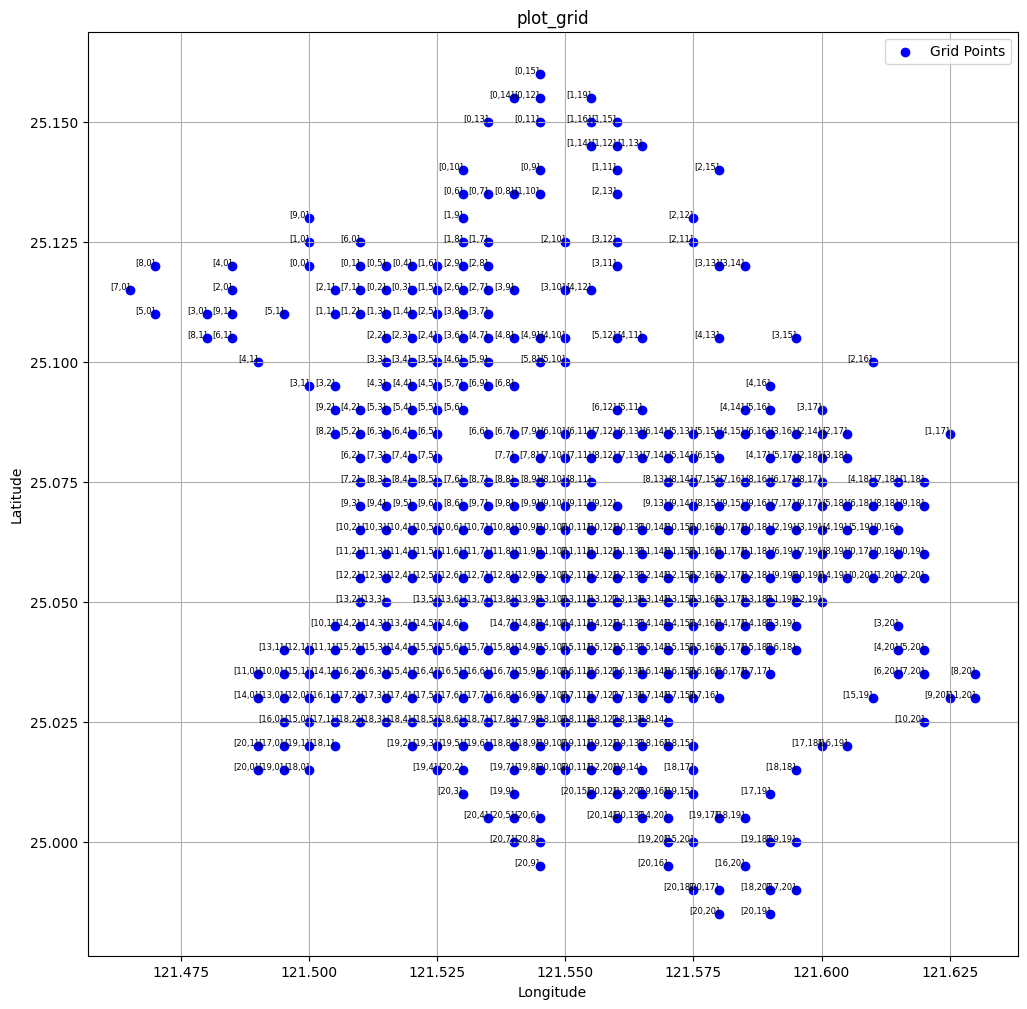

In [23]:
######################################
# 5. 主程式：數據分割與模型訓練、生成、評估
######################################
if __name__ == "__main__":
    # 網格尺寸與序列長度設定
    H = 21                     # 網格高度
    W = 21                     # 網格寬度
    condition_length = 8       # 歷史條件序列長度 (小時數)
    prediction_length = 1      # 預測序列長度 (小時數)
    batch_size = 32             # 每個 batch 的樣本數
    epochs = 100               # 訓練週期數
    lr = 0.001                  # 學習率
    timesteps = 1000            # 擴散步數
    patience = 10

    # 設定種子以確保實驗可重複性
    torch.manual_seed(42)
    np.random.seed(42)

    # 根據是否有 GPU 決定設備
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    # 初始化數據集，指定 CSV 檔案路徑 (請確認檔案名稱與路徑正確)
    full_dataset = PeopleFlowDatasetCondition(
        csv_path=r"C:\thesis\code\Taipei_CF\all_merged.csv",
        H=H,
        W=W,
        condition_length=condition_length,
        prediction_length=prediction_length,
        normalize=False,
        debug=True
    )
    dataset_size = len(full_dataset)
    logging.info(f"Full dataset length: {dataset_size}")

    # 按比例分割數據集：70% 訓練、15% 驗證、15% 測試
    train_end = int(0.7 * dataset_size)
    val_end = int(0.85 * dataset_size)
    train_dataset = Subset(full_dataset, range(0, train_end))
    val_dataset = Subset(full_dataset, range(train_end, val_end))
    test_dataset = Subset(full_dataset, range(val_end, dataset_size))
    logging.info(f"Dataset split: Train {len(train_dataset)}, Val {len(val_dataset)}, Test {len(test_dataset)}")

    # 建立 DataLoader，用於批次讀取數據
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    # 初始化 3D UNet 模型，並建立 DDPM 模型
    unet_3d = UNet3D(
        in_channels=9,          # 1未來 + 8過去
        base_channels=64,       # 提高至64
        time_emb_dim=TIME_EMB_DIM,
        dropout_rate=0.0
    )
    diffusion = DDPM3D(model=unet_3d, timesteps=timesteps, beta_start=1e-4, beta_end=0.02, device=device)

In [24]:
# 開始訓練 DDPM 模型
trained_diffusion = train_ddpm(diffusion, train_loader, val_loader, epochs=epochs, lr=lr, device=device, patience=patience)

ValueError: Input and output must have the same number of spatial dimensions, but got input with spatial dimensions of [1, 4, 4] and output size of torch.Size([5, 5]). Please provide input tensor in (N, C, d1, d2, ...,dK) format and output size in (o1, o2, ...,oK) format.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 視覺化生成的預測結果與真實值比較
def visualize_predictions(cond, generated, target, sample_idx=0, save_dir=r"C:\thesis\code\result_ddpm"):
    os.makedirs(save_dir, exist_ok=True)

    pred_length = generated.shape[2]  # 預測序列長度

    for t in range(pred_length):
        plt.figure(figsize=(12, 4))

        # 模型生成預測結果
        plt.subplot(1, 3, 1)
        plt.imshow(generated[sample_idx, 0, t].cpu().numpy(), cmap='viridis')
        plt.colorbar()
        plt.title(f'Generated Prediction (t={t})')

        # 真實人流數據
        plt.subplot(1, 3, 2)
        plt.imshow(target[sample_idx, 0, t].cpu().numpy(), cmap='viridis')
        plt.colorbar()
        plt.title(f'True Data (t={t})')

        # 誤差熱圖（差異圖）
        plt.subplot(1, 3, 3)
        error = np.abs(generated[sample_idx, 0, t].cpu().numpy() - target[sample_idx, 0, t].cpu().numpy())
        plt.imshow(error, cmap='hot')
        plt.colorbar()
        plt.title(f'Absolute Error (t={t})')

        plt.suptitle(f'Sample {sample_idx} - Time Step {t}', fontsize=16)
        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # 儲存圖片
        save_path = os.path.join(save_dir, f'prediction_sample{sample_idx}_t{t}.png')
        plt.savefig(save_path, dpi=300)
        plt.close()

# 測試生成流程：根據部分條件數據生成預測結果
sample_count = 8
sample_shape = (sample_count, 1, prediction_length, H, W)
cond_batch, _ = next(iter(val_loader))
cond_batch = cond_batch.to(device)
generated = trained_diffusion.p_sample_loop(sample_shape, cond_batch[:sample_count])
logging.info(f"Generated shape: {generated.shape}")

# 呼叫視覺化函數，選擇第一個樣本 (index=0) 做展示
_, target_batch = next(iter(val_loader))
visualize_predictions(cond_batch, generated, target_batch.to(device), sample_idx=0)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """
    返回一個截斷後的 colormap，只取原 colormap 的[minval, maxval]區間。
    """
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f'truncated({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

def plot_grid_with_error(sorted_flow_columns, H, W, error_matrix, 
                         save_path=r"C:\thesis\code\result_ddpm\plot_grid_with_error.png"):
    """
    顯示網格排列結果並將模型預測的均方誤差 (MSE) 標示於各網格座標，
    使用橘色到紅色的色系（避免太淺的色調）。
    
    此處 error_matrix 是基於原始數據計算得到的平均絕對誤差，
    並取平方以獲得每個網格點的 MSE。
    
    Args:
        sorted_flow_columns (list): 排序後的欄位名稱列表，包含經緯度座標。
        H (int): 網格高度。
        W (int): 網格寬度。
        error_matrix (np.ndarray): 誤差數值矩陣 (形狀應為 (H, W))。
        save_path (str): 圖片儲存路徑。
    """
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    import numpy as np

    # 解析各個欄位的經緯度
    locations = [parse_lat_lon(col) for col in sorted_flow_columns]
    longitudes, latitudes = zip(*locations)
    
    # 將誤差取平方，得到 MSE
    mse_matrix = error_matrix ** 2

    plt.figure(figsize=(12, 12))
    orig_cmap = plt.get_cmap('OrRd')
    trunc_cmap = truncate_colormap(orig_cmap, 0.3, 1.0)
    
    scatter = plt.scatter(longitudes, latitudes, c=mse_matrix.flatten(), cmap=trunc_cmap, marker='o')
    plt.colorbar(scatter, label='MSE')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Grid with MSE")
    plt.grid(True)
    plt.savefig(save_path, dpi=600, bbox_inches='tight', pad_inches=0.1)
    plt.close()

    # 整理成表格
    table_data = {
        'Grid Index': [],
        'Longitude': [],
        'Latitude': [],
        'MSE': []
    }
    
    for i in range(H):
        for j in range(W):
            idx = i * W + j
            table_data['Grid Index'].append(f'[{i},{j}]')
            table_data['Longitude'].append(longitudes[idx])
            table_data['Latitude'].append(latitudes[idx])
            table_data['MSE'].append(mse_matrix[i, j])

    # 創建 DataFrame
    df = pd.DataFrame(table_data)
    
    # 保存表格為 CSV 文件
    save_dir = os.path.dirname(save_path)
    table_save_path = os.path.join(save_dir, 'mse_per_coordinate.csv')
    df.to_csv(table_save_path, index=False)
    logging.info(f"MSE per coordinate table saved to {table_save_path}")

    # 可選：保存為 Excel 文件
    excel_save_path = os.path.join(save_dir, 'mse_per_coordinate.xlsx')
    df.to_excel(excel_save_path, index=False)
    logging.info(f"MSE per coordinate table saved to {excel_save_path}")


# 範例：假設 generated 是預測結果，target_batch 為實際數據，取第一個樣本及第一個預測時間點
import numpy as np

generated_sample = generated[0, 0, 0].cpu().numpy()
target_sample = target_batch[0, 0, 0].cpu().numpy()

# 計算誤差矩陣
# 結果形狀為 (1, H, W)，接著取第一個通道得到 (H, W)
generated = trained_diffusion.p_sample_loop(sample_shape, cond_batch[:sample_count])
# 計算所有樣本與時間步的平均絕對誤差矩陣：
# 首先計算絕對誤差，再在 axis=(0, 2) 進行平均，得到形狀 (1, H, W)，取第一個通道得到 (H, W)
error_matrix = torch.abs(generated - target_batch[:sample_count].to(device)).cpu().numpy()
error_matrix = np.mean(error_matrix, axis=(0,2))[0]

# 視覺化到座標網格上
plot_grid_with_error(full_dataset.sorted_flow_columns, H, W, error_matrix)


# 評估模型重構誤差 (MSE)，使用部分驗證數據進行測試
max_samples = 100
recon_metrics = evaluate_model(trained_diffusion, val_dataset, device=device, max_samples=100)
logging.info(f"Reconstruction MSE : {recon_metrics['mse']:.6f}")
logging.info(f"Reconstruction MAE : {recon_metrics['mae']:.6f}")

# 保存評估結果到文件
save_dir = r"C:\thesis\code\result_ddpm"
os.makedirs(save_dir, exist_ok=True)
    
# 將評估指標保存為文本文件
metrics_file = os.path.join(save_dir, "evaluation_metrics.txt")
with open(metrics_file, 'w') as f:
    f.write(f"Evaluation Metrics (computed on {max_samples} samples):\n")
    f.write(f"Date: {pd.Timestamp.now()}\n")
    f.write(f"Reconstruction MSE: {recon_metrics['mse']:.6f}\n")
    f.write(f"Reconstruction MAE: {recon_metrics['mae']:.6f}\n")
    
# 將評估指標保存為JSON文件（便於後續程式讀取）
import json
metrics_json_file = os.path.join(save_dir, "evaluation_metrics.json")
with open(metrics_json_file, 'w') as f:
    json.dump({
        "mse": recon_metrics['mse'],
        "mae": recon_metrics['mae'],
        "sample_size": max_samples,
        "timestamp": pd.Timestamp.now().isoformat()
    }, f, indent=4)

logging.info(f"Evaluation metrics saved to {metrics_file} and {metrics_json_file}")

# # 可選：保存生成的樣本數據為numpy檔案
# generated_np = generated.cpu().numpy()
# np.save(os.path.join(save_dir, "generated_samples.npy"), generated_np)
# logging.info(f"Generated samples saved to {os.path.join(save_dir, 'generated_samples.npy')}")